# Solver hyperparameters

The minimum SWEEP call is

```python
solver = PropTorch(Acoustic(device=device), shape=shape, dh=dh, dt=dt)
```

but `PropTorch` accepts a dozen more knobs that control accuracy, memory, absorbing boundaries, autograd behaviour, and which compute backend is used. This notebook walks through the two that move the dial the most in practice — `spatial_order` and `pml_type` / `abcn` — and gives quick pointers for the rest.

The headline experiment: dial `spatial_order` from 2 → 4 → 8 on a uniform medium and watch grid dispersion shrink in the wavefield snapshot.

## 1. Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic, Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 2. Acoustic — `spatial_order` 2 vs 4 vs 8

A centred Ricker source in a homogeneous 2000 m/s medium, snapshot at t ≈ 0.4 s. With the default 4th-order stencil and ~4 ppw (points per wavelength) the wavefront is already crisp; at 2nd order you can clearly see a trailing dispersion tail behind the front; at 8th order the front gets visibly sharper.

Time and grid are tuned to give marginal ppw on purpose — you only see dispersion when the stencil is the resolution bottleneck.

In [2]:
shape    = (181, 181)
dh, dt   = 10.0, 1e-3
nt       = 500
freq     = 30.0
delay    = 0.08
abcn     = 30
vp_val   = 2000.0
snapshot_time = 320          # ~0.32 s — wavefront reaches mid-grid

src_iz, src_ix = shape[0] // 2, shape[1] // 2
sources   = np.array([[src_ix, src_iz]], dtype=np.int64)
receivers = np.array([[[src_ix, src_iz + 4]]], dtype=np.int64)
t = np.arange(nt, dtype=np.float32) * dt
wavelet = ricker(t - delay, f=freq).astype(np.float32)

def run_acoustic(order):
    eq = Acoustic(spatial_order=order, device=device)
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, dev=device,
                       abcn=abcn, use_ckpt=False, impl='eager')
    vp = torch.full(shape, vp_val, device=device)
    with torch.no_grad():
        _, snaps = solver(wavelet, sources, receivers, models=[vp],
                          return_wavefield=True, snapshot_times=[snapshot_time])
    return snaps[0, 0, 0, 0, abcn:abcn + shape[0], abcn:abcn + shape[1]].cpu().numpy()

orders = [2, 4, 8]
acoustic_panels = [run_acoustic(o) for o in orders]
ppw = vp_val / freq / dh
print(f'points per wavelength (vp/f/dh): {ppw:.1f}')
print('acoustic fields ready, shapes:', [p.shape for p in acoustic_panels])

points per wavelength (vp/f/dh): 6.7
acoustic fields ready, shapes: [(181, 181), (181, 181), (181, 181)]


### Aside · which sources and receivers does this equation accept?

`Acoustic` publishes a structured field table — query `eq.models` for the
expected model input order, `available_source_fields()` / `available_receiver_fields()`
for valid source / receiver options. See the
[Equations user guide](../../user-guide/equations/) for the full rundown.

In [3]:
from sweep.equations import Acoustic
eq = Acoustic(device=device)
print('models (input order matters!):')
for spec in eq.MODEL_SPECS:
    unit = f' [{spec.unit}]' if spec.unit else ''
    print(f'  - {spec.name:8s}{unit}  — {spec.description}')
print('defaults  :', eq.default_source_fields, '/', eq.default_receiver_fields)
print('receivers :')
for spec in eq.available_receiver_fields():
    print(f'  - {spec.name:8s} aliases={spec.aliases}  — {spec.description}')

models (input order matters!):
  - vp       [m/s]  — Acoustic P-wave velocity model.
defaults  : ['h1'] / ['h1']
receivers :
  - h1       aliases=('pressure', 'p')  — Primary acoustic pressure-like wavefield.


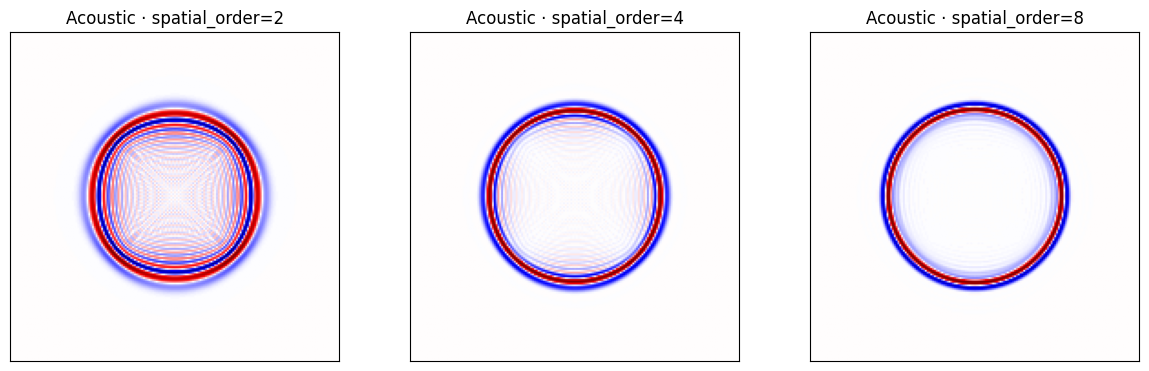

In [4]:
vmax = max(np.percentile(np.abs(p), 99.5) for p in acoustic_panels)
fig, axes = plt.subplots(1, len(orders), figsize=(12, 3.6), constrained_layout=True)
for ax, panel, o in zip(axes, acoustic_panels, orders):
    ax.imshow(panel, cmap='seismic', aspect='equal', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Acoustic · spatial_order={o}')
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

Higher order ⇒ cleaner front, but each step costs more compute and the stencil halo grows. The default `spatial_order=4` is a good balance for most production work; bump to 6–8 when the grid is coarse (few ppw).

## 3. Elastic — same story, two wavefronts

The elastic equation propagates a fast P-wavefront and a slow S-wavefront from a single explosion source (`sxx + szz`). Dispersion shows up first on the slower S-wave because it samples fewer ppw at the same grid spacing.

In [5]:
e_shape = (201, 201)
e_dh, e_dt, e_nt = 10.0, 0.8e-3, 800
e_freq, e_delay = 18.0, 0.16
e_abcn = 30
vp, vs, rho = 2200.0, 1000.0, 2000.0
e_snap = 550

e_src_iz, e_src_ix = e_shape[0] // 2, e_shape[1] // 2
e_sources   = np.array([[e_src_ix, e_src_iz]], dtype=np.int64)
e_receivers = np.array([[[e_src_ix, e_src_iz + 4]]], dtype=np.int64)
et = np.arange(e_nt, dtype=np.float32) * e_dt
e_wavelet = ricker(et - e_delay, f=e_freq).astype(np.float32)

def run_elastic(order):
    eq = Elastic(spatial_order=order, device=device)
    solver = PropTorch(eq, shape=e_shape, dh=e_dh, dt=e_dt, dev=device,
                       abcn=e_abcn, source_type=['sxx','szz'], receiver_type=['vz'],
                       use_ckpt=False, impl='eager')
    vp_t  = torch.full(e_shape, vp,  device=device)
    vs_t  = torch.full(e_shape, vs,  device=device)
    rho_t = torch.full(e_shape, rho, device=device)
    with torch.no_grad():
        _, snaps = solver(e_wavelet, e_sources, e_receivers,
                          models=[vp_t, vs_t, rho_t],
                          return_wavefield=True, snapshot_times=[e_snap])
    vz_idx = eq.wavefields.index('vz')
    return snaps[0, vz_idx, 0, 0, e_abcn:e_abcn + e_shape[0], e_abcn:e_abcn + e_shape[1]].cpu().numpy()

elastic_panels = [run_elastic(o) for o in orders]
print('elastic Vz fields ready')

elastic Vz fields ready


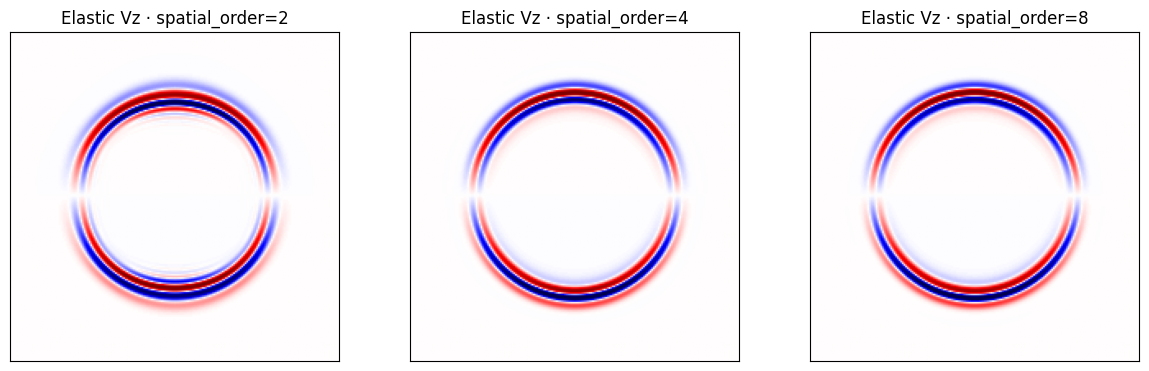

In [6]:
vmax = max(np.percentile(np.abs(p), 99.5) for p in elastic_panels)
fig, axes = plt.subplots(1, len(orders), figsize=(12, 3.6), constrained_layout=True)
for ax, panel, o in zip(axes, elastic_panels, orders):
    ax.imshow(panel, cmap='seismic', aspect='equal', vmin=-vmax, vmax=vmax)
    ax.set_title(f'Elastic Vz · spatial_order={o}')
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 4. Other solver knobs worth knowing

| Argument | What it controls | When to change |
|---|---|---|
| `pml_type` | Absorbing boundary formulation. `cpmlr` (recursive CPML) for 2nd-order acoustic, `cpmls` (staggered) for elastic / DAS. `spml` is the legacy split-PML. | Match it to the equation — most users never touch it. |
| `abcn` | Width (in cells) of the PML strip wrapped around the interior model. | Bump up (40–60) if you see reflections off the model edges; cut down to ~20 if memory is tight. |
| `free_surface` | Toggle a free-surface boundary at `z = 0` (ghost-image method). | Enable for land / OBN acquisitions with a free top. |
| `use_ckpt` | Whether to checkpoint the forward time loop so the backward fits in memory. `True` by default. | Set `False` when you need `return_wavefield=True` or when the forward already fits. |
| `impl` | `'eager'` runs the PyTorch operators directly (always available, fully autograd-traced); `'c'` calls the compiled C++/CUDA extension (~5–20× faster). | Use `'c'` for production / batch FWI runs; stay on `'eager'` for development and debugging. |
| `spatial_order` | Half-width of the FD stencil for spatial derivatives. Default `4`. | Bump to 6–8 if you're undersampling (few ppw); drop to 2 only for cheap validation runs. |

All of these are kwargs on `PropTorch`. See [`docs/api/propagators/options.md`](../../api/propagators/options/) for the full reference.

---

**Download this notebook** &mdash; [`09_solver_hyperparams.ipynb`](https://github.com/DeepWave-KAUST/sweep/raw/main/examples/notebooks/09_solver_hyperparams/)
&middot; or [browse on GitHub](https://github.com/DeepWave-KAUST/sweep/blob/main/examples/notebooks/09_solver_hyperparams/)